# Análisis Exploratorio y Preparación de Datos — Bank Marketing Dataset

**Dataset:** [Bank Marketing — UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/bank+marketing)  
**Objetivo:** Predecir si un cliente suscribirá un depósito a plazo fijo (`y = yes/no`).  
**Alcance de este notebook:** Análisis exploratorio de datos (EDA) y preparación del conjunto para modelado posterior.

---

## 1. Importación de librerías

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('Librerías importadas correctamente.')

Librerías importadas correctamente.


---
## 2. Carga del dataset

El archivo `bank-full.csv` usa **punto y coma** (`;`) como separador, formato propio del repositorio UCI.

In [32]:
df = pd.read_csv('bank-full.csv', sep=';')
print(f'Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
df.head()

Dataset cargado: 45,211 filas × 17 columnas


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


---
## 3. Inspección inicial

Revisamos la estructura general del dataset antes de cualquier transformación.

In [33]:
print('=== Shape ===')
print(f'Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}')

=== Shape ===
Filas: 45,211  |  Columnas: 17


In [34]:
print('=== Info ===')
df.info()

=== Info ===
<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [35]:
print('=== Estadísticas descriptivas — variables numéricas ===')
df.describe().T.round(2)

=== Estadísticas descriptivas — variables numéricas ===


,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.94,10.62,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.27,3044.77,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.81,8.32,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.16,257.53,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.76,3.10,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.20,100.13,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.58,2.30,0.0,0.0,0.0,0.0,275.0


In [36]:
print('=== Estadísticas descriptivas — variables categóricas ===')
df.describe(include='object').T

=== Estadísticas descriptivas — variables categóricas ===


,count,unique,top,freq
job,45211,12,blue-collar,9732
marital,45211,3,married,27214
education,45211,4,secondary,23202
default,45211,2,no,44396
housing,45211,2,yes,25130
loan,45211,2,no,37967
contact,45211,3,cellular,29285
month,45211,12,may,13766
poutcome,45211,4,unknown,36959
y,45211,2,no,39922


---
## 4. Análisis de la variable objetivo `y`

Verificamos si el dataset está **desbalanceado**, lo que determinará estrategias de modelado posteriores.

     Cantidad  Porcentaje (%)
y                            
no      39922            88.3
yes      5289            11.7


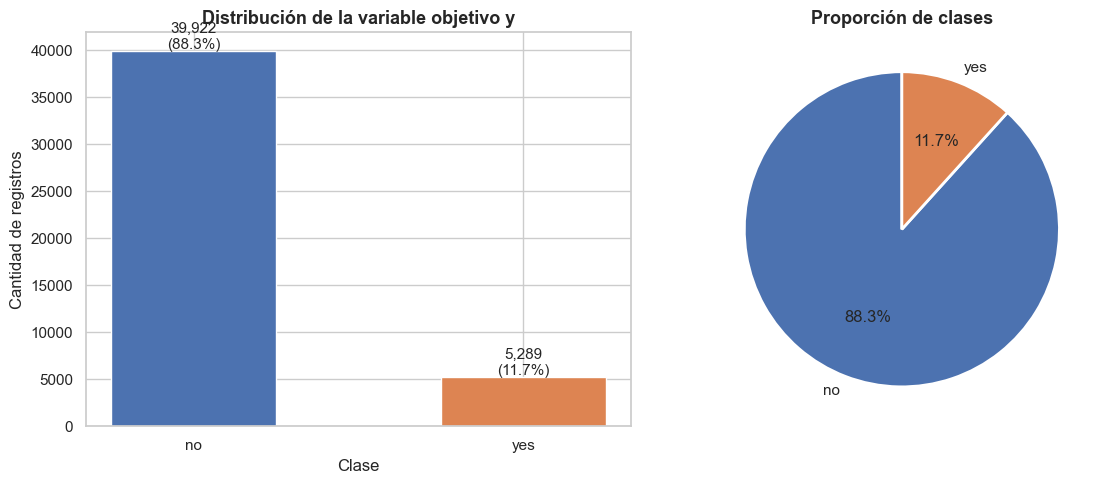


Ratio desbalance (no/yes): 7.5:1
⚠  Dataset fuertemente desbalanceado. Considerar SMOTE, class_weight o threshold tuning al modelar.


In [37]:
conteo = df['y'].value_counts()
pct    = df['y'].value_counts(normalize=True) * 100

resumen_y = pd.DataFrame({'Cantidad': conteo, 'Porcentaje (%)': pct.round(2)})
print(resumen_y)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de barras
axes[0].bar(conteo.index, conteo.values, color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
axes[0].set_title('Distribución de la variable objetivo y', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Cantidad de registros')
for i, (cls, val) in enumerate(zip(conteo.index, conteo.values)):
    axes[0].text(i, val + 200, f'{val:,}\n({pct[cls]:.1f}%)', ha='center', fontsize=11)

# Gráfico de pastel
axes[1].pie(conteo.values, labels=conteo.index, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción de clases', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = conteo['no'] / conteo['yes']
print(f'\nRatio desbalance (no/yes): {ratio:.1f}:1')
print('⚠  Dataset fuertemente desbalanceado. Considerar SMOTE, class_weight o threshold tuning al modelar.')

---
## 5. Valores faltantes

El dataset UCI no tiene `NaN` explícitos, pero la categoría **`"unknown"`** actúa como sustituto de dato faltante en varias columnas.

In [38]:
# NaN reales
nulos = df.isnull().sum()
print('=== NaN explícitos ===')
print(nulos[nulos > 0] if nulos.sum() > 0 else 'No hay valores NaN en el dataset.')

# "unknown" como valor implícito faltante
print('\n=== Categoría "unknown" por columna ===')
cols_obj = df.select_dtypes(include='object').columns
unknown_counts = {}
for col in cols_obj:
    n = (df[col] == 'unknown').sum()
    if n > 0:
        unknown_counts[col] = {'Cantidad': n, 'Porcentaje (%)': round(n / len(df) * 100, 2)}

if unknown_counts:
    print(pd.DataFrame(unknown_counts).T.sort_values('Porcentaje (%)', ascending=False))
else:
    print('No hay valores "unknown".')

=== NaN explícitos ===
No hay valores NaN en el dataset.

=== Categoría "unknown" por columna ===
           Cantidad  Porcentaje (%)
poutcome    36959.0           81.75
contact     13020.0           28.80
education    1857.0            4.11
job           288.0            0.64


**Interpretación:**  
- `contact` y `poutcome` concentran la mayoría de los `"unknown"`. Esto es esperado según la descripción del dataset.  
- Por ahora se mantienen como categoría propia; el impacto real se evaluará en el modelado.

---
## 6. Registros duplicados

In [39]:
n_dup = df.duplicated().sum()
print(f'Registros duplicados: {n_dup}')

if n_dup > 0:
    print('Se eliminarán los duplicados.')
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Shape tras eliminación: {df.shape}')
else:
    print('No hay duplicados. El dataset permanece intacto.')

Registros duplicados: 0
No hay duplicados. El dataset permanece intacto.


---
## 7. Análisis de variables

### 7.1 Clasificación de variables

In [40]:
vars_num = df.select_dtypes(include=[np.number]).columns.tolist()
vars_cat = df.select_dtypes(include='object').columns.tolist()
vars_cat.remove('y')  # excluimos el target

print(f'Variables numéricas ({len(vars_num)}): {vars_num}')
print(f'Variables categóricas ({len(vars_cat)}) (sin y): {vars_cat}')

Variables numéricas (7): ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Variables categóricas (9) (sin y): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


### 7.2 Variables numéricas — estadísticas por clase objetivo

In [41]:
print('Mediana de variables numéricas por clase objetivo:')
df.groupby('y')[vars_num].median().T.round(2)

Mediana de variables numéricas por clase objetivo:


y,no,yes
age,39.0,38.0
balance,417.0,733.0
day,16.0,15.0
duration,164.0,426.0
campaign,2.0,2.0
pdays,-1.0,-1.0
previous,0.0,0.0


### 7.3 Variables categóricas — cardinalidad

In [42]:
card = pd.DataFrame({
    'Valores únicos': [df[c].nunique() for c in vars_cat],
    'Categorías': [df[c].unique().tolist() for c in vars_cat]
}, index=vars_cat)
card

,Valores únicos,Categorías
job,12,"[management, technician, entrepreneur, blue-co..."
marital,3,"[married, single, divorced]"
education,4,"[tertiary, secondary, unknown, primary]"
default,2,"[no, yes]"
housing,2,"[yes, no]"
loan,2,"[no, yes]"
contact,3,"[unknown, cellular, telephone]"
month,12,"[may, jun, jul, aug, oct, nov, dec, jan, feb, ..."
poutcome,4,"[unknown, failure, other, success]"


---
## 8. Visualizaciones

### 8.1 Histogramas — variables numéricas

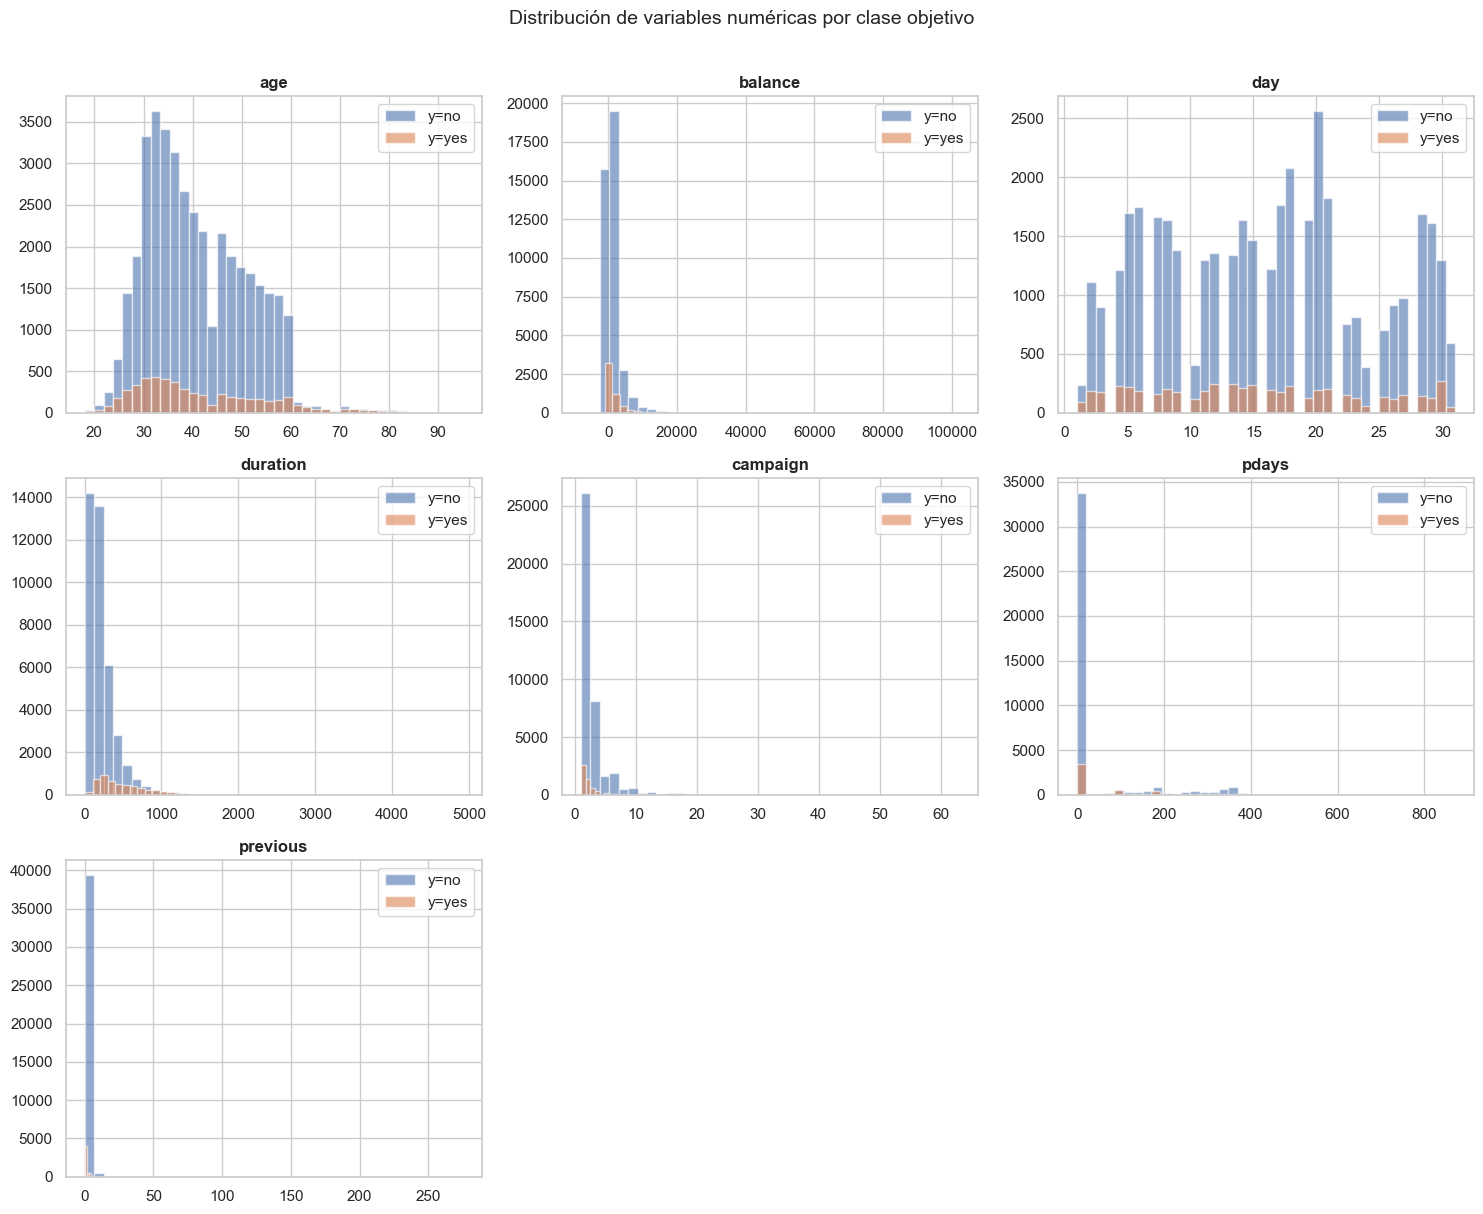

In [43]:
n_cols = 3
n_rows = int(np.ceil(len(vars_num) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(vars_num):
    for cls, color in zip(['no', 'yes'], ['#4C72B0', '#DD8452']):
        axes[i].hist(df.loc[df['y'] == cls, col], bins=40, alpha=0.6,
                     color=color, label=f'y={cls}', edgecolor='white')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].legend()

# Ocultar ejes sobrantes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables numéricas por clase objetivo', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('histogramas.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.2 Boxplots — detección visual de outliers

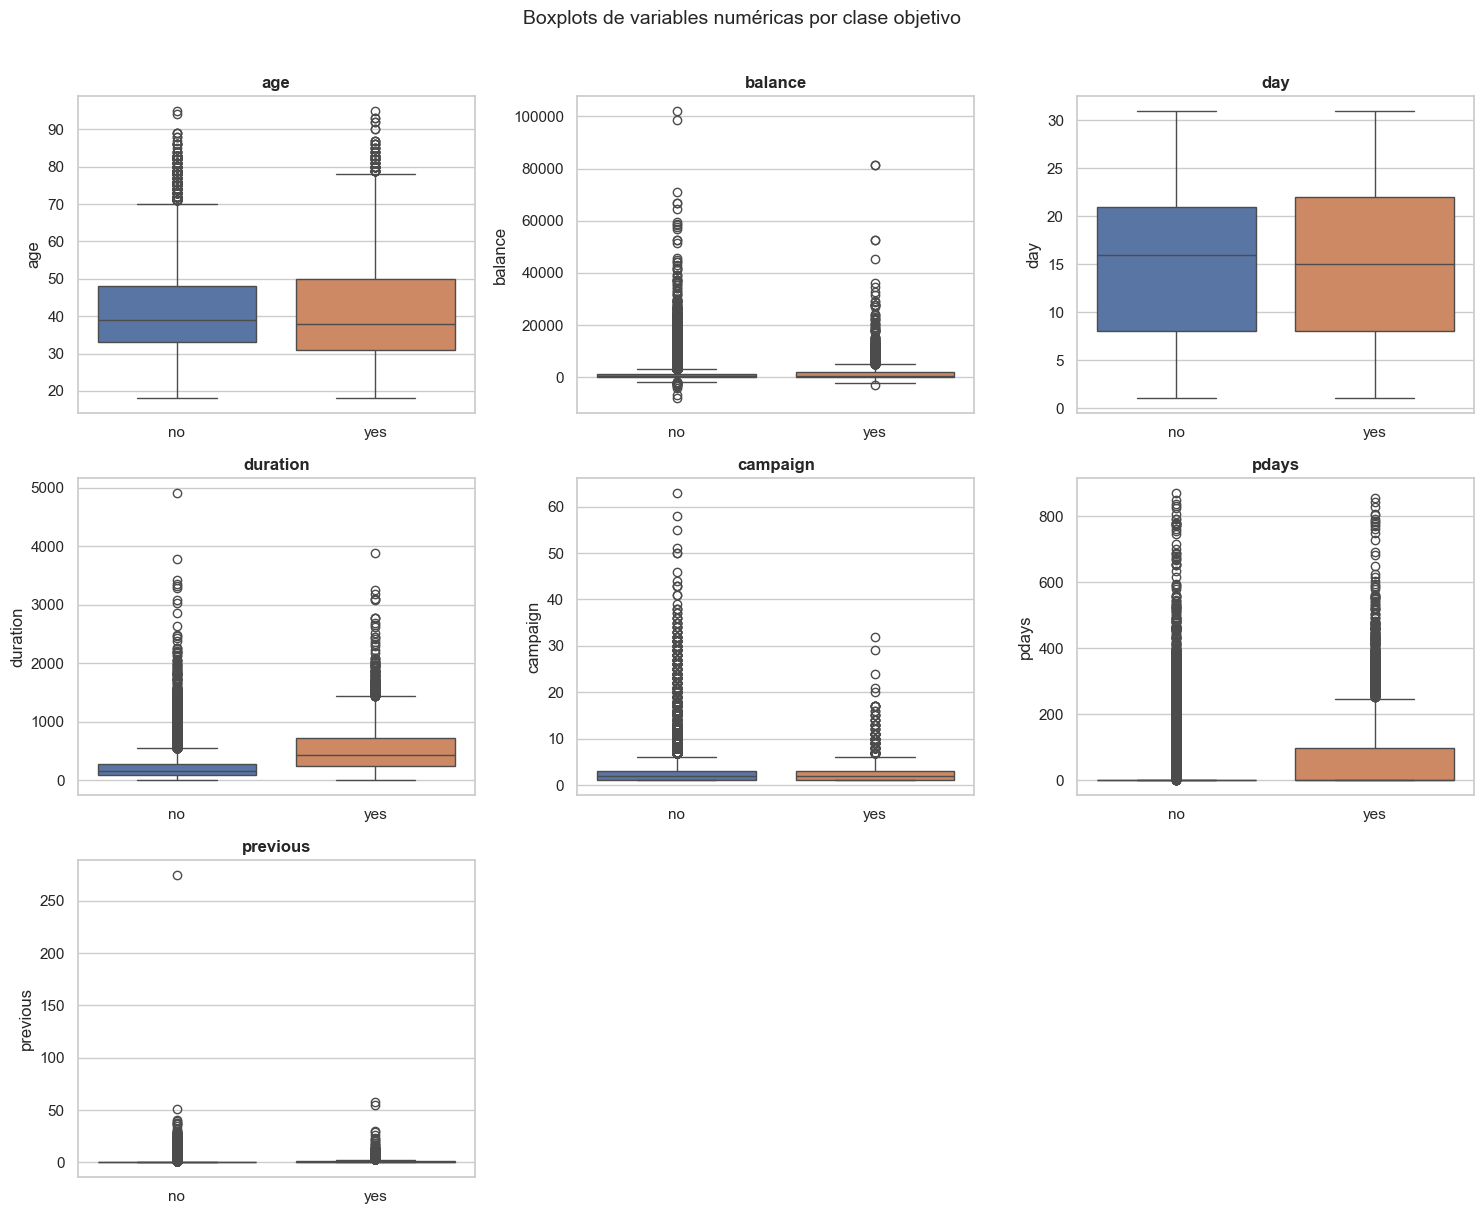

In [44]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(vars_num):
    sns.boxplot(data=df, x='y', y=col, ax=axes[i],
                palette={'no': '#4C72B0', 'yes': '#DD8452'},
                order=['no', 'yes'])
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots de variables numéricas por clase objetivo', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.3 Matriz de correlación

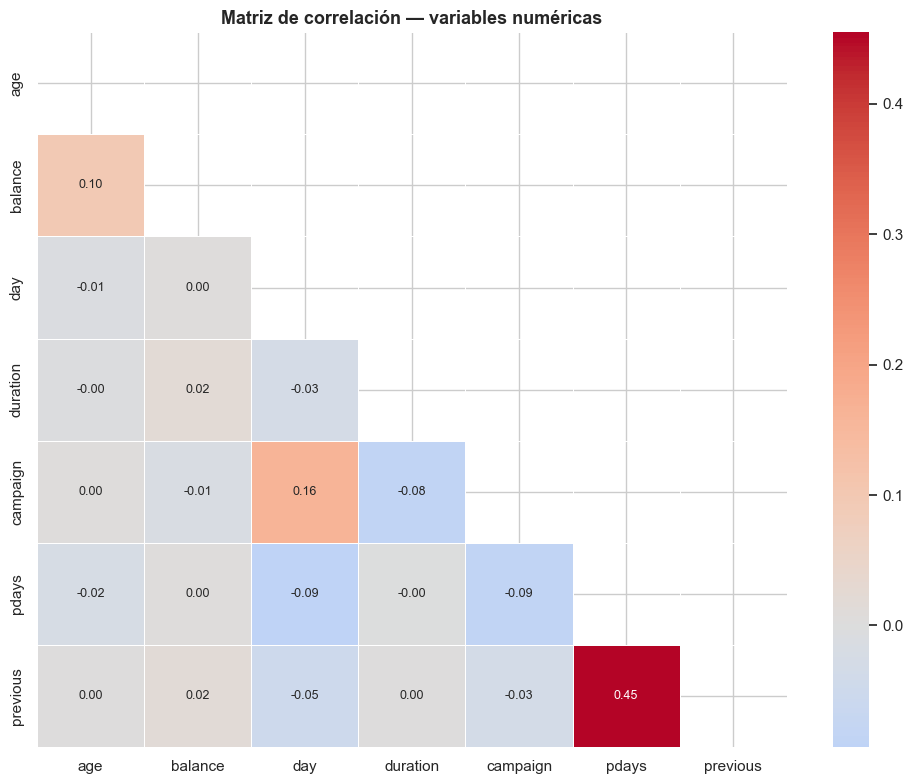

Pares con |correlación| > 0.5:
Ninguno.


In [45]:
corr = df[vars_num].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Matriz de correlación — variables numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

# Pares con alta correlación (|r| > 0.5)
corr_pairs = (corr.abs().where(mask == False)
                  .stack()
                  .reset_index()
                  .rename(columns={'level_0': 'Var1', 'level_1': 'Var2', 0: '|r|'})
                  .query('`|r|` > 0.5')
                  .sort_values('|r|', ascending=False))
print('Pares con |correlación| > 0.5:')
print(corr_pairs if not corr_pairs.empty else 'Ninguno.')

### 8.4 Countplots — variables categóricas vs. variable objetivo

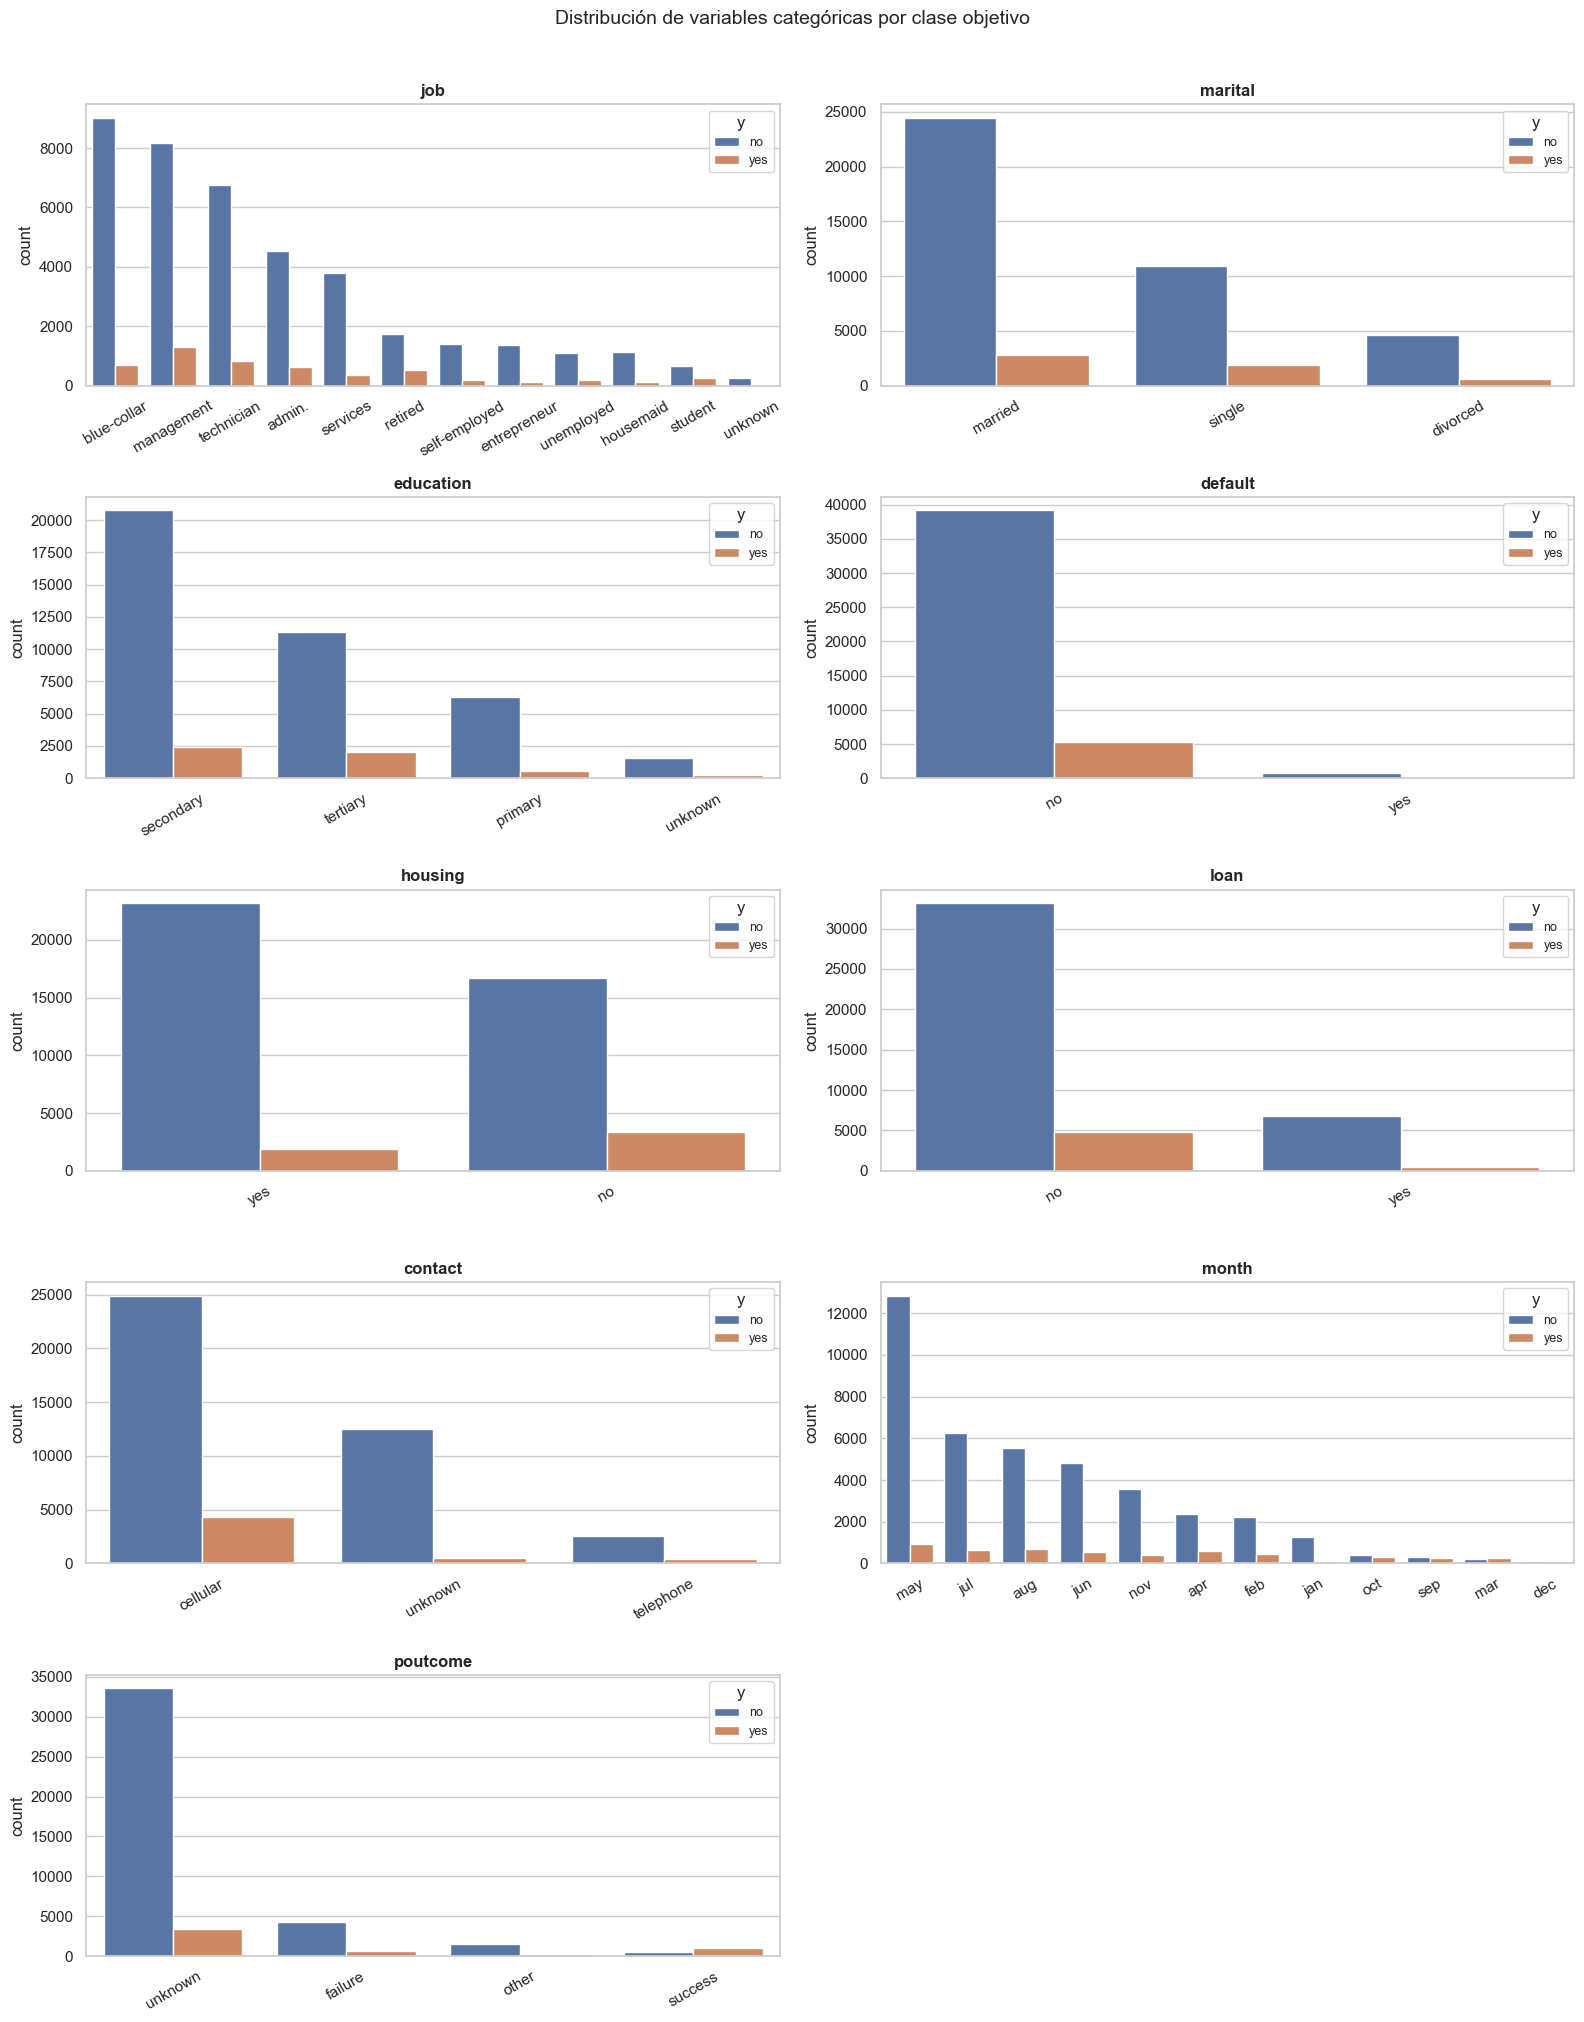

In [46]:
n_cols_cat = 2
n_rows_cat = int(np.ceil(len(vars_cat) / n_cols_cat))

fig, axes = plt.subplots(n_rows_cat, n_cols_cat, figsize=(16, n_rows_cat * 4))
axes = axes.flatten()

for i, col in enumerate(vars_cat):
    # Ordenar categorías por frecuencia total para mejor legibilidad
    order = df[col].value_counts().index.tolist()
    sns.countplot(data=df, x=col, hue='y', ax=axes[i], order=order,
                  palette={'no': '#4C72B0', 'yes': '#DD8452'})
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='y', fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables categóricas por clase objetivo', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('countplots.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Detección de outliers (método IQR)

Cuantificamos los outliers usando la regla IQR: un punto es outlier si cae fuera del rango `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]`.

In [47]:
def iqr_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    mask = (series < lower) | (series > upper)
    return mask.sum(), lower, upper

outlier_info = []
for col in vars_num:
    n_out, lo, hi = iqr_outliers(df[col])
    outlier_info.append({
        'Variable': col,
        'N outliers': n_out,
        '% outliers': round(n_out / len(df) * 100, 2),
        'Limite inferior': round(lo, 2),
        'Limite superior': round(hi, 2)
    })

df_out = pd.DataFrame(outlier_info).set_index('Variable').sort_values('N outliers', ascending=False)
df_out

,N outliers,% outliers,Limite inferior,Limite superior
Variable,,,,
previous,8257,18.26,0.0,0.0
pdays,8257,18.26,-1.0,-1.0
balance,4729,10.46,-1962.0,3462.0
duration,3235,7.16,-221.0,643.0
campaign,3064,6.78,-2.0,6.0
age,487,1.08,10.5,70.5
day,0,0.00,-11.5,40.5


**Interpretación:**  
- Variables como `balance`, `campaign`, `pdays` y `previous` muestran outliers significativos. Esto es esperable en datos financieros y de campañas de marketing.  
- En lugar de eliminarlos, el **StandardScaler** posterior reducirá su impacto. Para algoritmos sensibles a escala (como SVM o KNN), considerar RobustScaler.

---
## 10. Variable `duration` y el problema de Data Leakage

### ¿Qué representa `duration`?

> *"Duración del último contacto telefónico, en segundos."*

### ¿Por qué genera data leakage?

| Escenario | Realidad |
|---|---|
| `duration` muy alta (> 500 s) | Alta probabilidad de `y = yes` |
| `duration = 0` | El cliente nunca fue contactado → `y = no` automáticamente |

**El problema:** esta variable **solo se conoce después de que la llamada termina**, es decir, después de que el evento objetivo ya ocurrió. En producción, antes de realizar la llamada, su valor es desconocido.

Incluirla en el modelo generaría una **métrica artificialmente alta** que no se replicaría en datos reales.

### Decisión

Se **excluye `duration`** del conjunto de features, siguiendo la recomendación oficial de los autores del dataset.

Mediana de duration:
  y=no:  164 s
  y=yes: 426 s


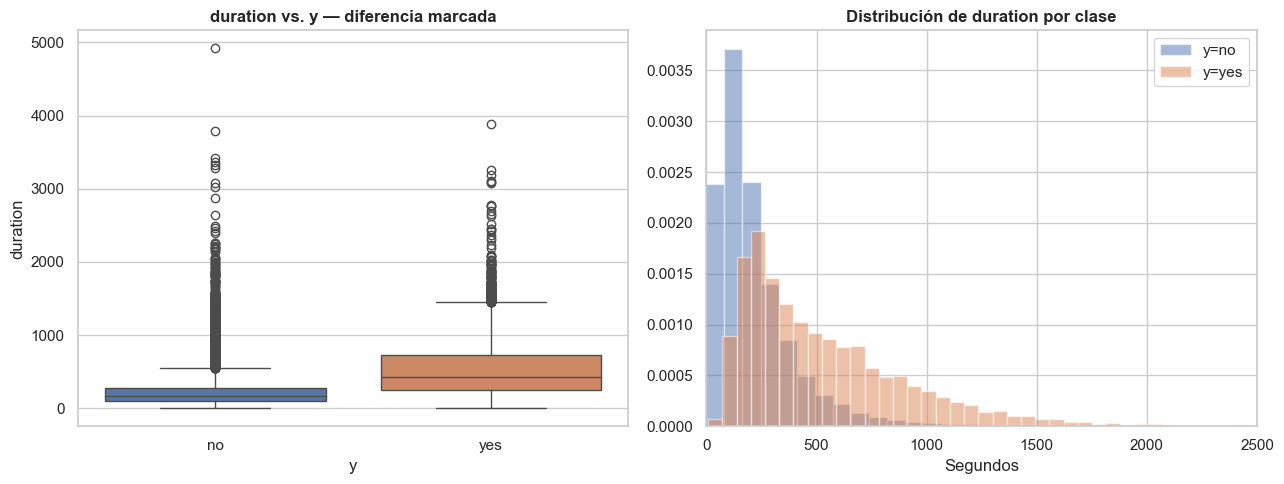


⚠  duration se EXCLUIRÁ del dataset de modelado para evitar data leakage.


In [48]:
# Visualizar la relación entre duration y la clase objetivo para evidenciar el leakage
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x='y', y='duration', ax=axes[0],
            palette={'no': '#4C72B0', 'yes': '#DD8452'}, order=['no', 'yes'])
axes[0].set_title('duration vs. y — diferencia marcada', fontsize=12, fontweight='bold')

medians = df.groupby('y')['duration'].median()
print(f'Mediana de duration:\n  y=no:  {medians["no"]:.0f} s\n  y=yes: {medians["yes"]:.0f} s')

# Distribución de duración por clase (KDE)
for cls, color in zip(['no', 'yes'], ['#4C72B0', '#DD8452']):
    subset = df.loc[df['y'] == cls, 'duration']
    axes[1].hist(subset, bins=60, alpha=0.5, color=color, label=f'y={cls}', density=True)
axes[1].set_xlim(0, 2500)
axes[1].set_title('Distribución de duration por clase', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Segundos')
axes[1].legend()

plt.tight_layout()
plt.savefig('duration_leakage.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n⚠  duration se EXCLUIRÁ del dataset de modelado para evitar data leakage.')

---
## 11. Preparación de datos

### 11.1 Separar X e y — excluir `duration`

In [49]:
FEATURES_EXCLUIR = ['duration']

X = df.drop(columns=['y'] + FEATURES_EXCLUIR)
y = df['y'].map({'no': 0, 'yes': 1})   # codificamos el target como 0/1

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'\nColumnas en X: {X.columns.tolist()}')

X shape: (45211, 15)
y shape: (45211,)

Columnas en X: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous', 'poutcome']


### 11.2 One-Hot Encoding para variables categóricas

Usamos `pd.get_dummies` con `drop_first=True` para evitar multicolinealidad (trampa de la variable dummy).

In [50]:
cat_cols = X.select_dtypes(include='object').columns.tolist()
print(f'Columnas categóricas a codificar: {cat_cols}')

X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print(f'\nShape antes de OHE: {X.shape}')
print(f'Shape después de OHE: {X_encoded.shape}')
print(f'Nuevas columnas generadas: {X_encoded.shape[1] - X.shape[1]}')

Columnas categóricas a codificar: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Shape antes de OHE: (45211, 15)
Shape después de OHE: (45211, 41)
Nuevas columnas generadas: 26


---
## 12. División entrenamiento / prueba

- **70% entrenamiento — 30% prueba**  
- `stratify=y`: mantiene la proporción de clases en ambos subconjuntos.  
- `random_state=42`: reproducibilidad.

In [51]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

print(f'X_train: {X_train_raw.shape}  |  y_train: {y_train.shape}')
print(f'X_test : {X_test_raw.shape}  |  y_test : {y_test.shape}')

print(f'\nProporción y=1 en train: {y_train.mean():.3f}')
print(f'Proporción y=1 en test : {y_test.mean():.3f}')

X_train: (31647, 41)  |  y_train: (31647,)
X_test : (13564, 41)  |  y_test : (13564,)

Proporción y=1 en train: 0.117
Proporción y=1 en test : 0.117


### 11.3 RobustScaler — solo variables numéricas

> **Regla de oro:** el scaler se **ajusta únicamente sobre el conjunto de entrenamiento** (`fit_transform`) y luego se aplica al de prueba (`transform`). Así evitamos *data leakage* de estadísticas del test set.

In [52]:
# Identificar columnas numéricas en el DataFrame ya codificado
# (las booleanas de OHE son int/bool; las numéricas originales siguen siendo float/int)
num_cols_encoded = [c for c in X_encoded.columns
                    if c in vars_num and c not in FEATURES_EXCLUIR]

print(f'Columnas a escalar: {num_cols_encoded}')

scaler = RobustScaler()

X_train = X_train_raw.copy()
X_test  = X_test_raw.copy()

X_train[num_cols_encoded] = scaler.fit_transform(X_train_raw[num_cols_encoded])
X_test[num_cols_encoded]  = scaler.transform(X_test_raw[num_cols_encoded])

print('\nScaler ajustado y aplicado correctamente.')

Columnas a escalar: ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']

Scaler ajustado y aplicado correctamente.


---
## 13. Dimensiones finales de los conjuntos

In [53]:
print('╔══════════════════════════════════════╗')
print('║      DIMENSIONES FINALES             ║')
print('╠══════════════════════════════════════╣')
print(f'║  X_train : {str(X_train.shape):<27}║')
print(f'║  X_test  : {str(X_test.shape):<27}║')
print(f'║  y_train : {str(y_train.shape):<27}║')
print(f'║  y_test  : {str(y_test.shape):<27}║')
print('╚══════════════════════════════════════╝')

print(f'\nTotal features: {X_train.shape[1]}')
print(f'Total registros de entrenamiento: {X_train.shape[0]:,}')
print(f'Total registros de prueba       : {X_test.shape[0]:,}')

╔══════════════════════════════════════╗
║      DIMENSIONES FINALES             ║
╠══════════════════════════════════════╣
║  X_train : (31647, 41)                ║
║  X_test  : (13564, 41)                ║
║  y_train : (31647,)                   ║
║  y_test  : (13564,)                   ║
╚══════════════════════════════════════╝

Total features: 41
Total registros de entrenamiento: 31,647
Total registros de prueba       : 13,564


---
## 14. Guardar conjuntos procesados

Exportamos los cuatro datasets a archivos CSV para ser utilizados directamente por el notebook de modelado, sin necesidad de repetir el preprocesamiento.

In [54]:
import os

OUTPUT_DIR = 'data_procesada'
os.makedirs(OUTPUT_DIR, exist_ok=True)

X_train.to_csv(f'{OUTPUT_DIR}/X_train.csv', index=False)
X_test.to_csv(f'{OUTPUT_DIR}/X_test.csv',  index=False)
y_train.to_csv(f'{OUTPUT_DIR}/y_train.csv', index=False)
y_test.to_csv(f'{OUTPUT_DIR}/y_test.csv',   index=False)

# También guardamos la lista de columnas para referencia en el notebook de modelado
pd.Series(X_train.columns.tolist()).to_csv(f'{OUTPUT_DIR}/feature_names.csv', index=False, header=['feature'])

print('Archivos guardados en la carpeta data_procesada/:')
for f in os.listdir(OUTPUT_DIR):
    size = os.path.getsize(os.path.join(OUTPUT_DIR, f)) / 1024
    print(f'  {f:<25} {size:.1f} KB')

print('\n✔ Preprocesamiento completado. Los conjuntos están listos para modelado.')

Archivos guardados en la carpeta data_procesada/:
  feature_names.csv         0.5 KB
  X_test.csv                3590.7 KB
  X_train.csv               8372.8 KB
  y_test.csv                39.7 KB
  y_train.csv               92.7 KB

✔ Preprocesamiento completado. Los conjuntos están listos para modelado.


---
## 15. Resumen ejecutivo del EDA

| Aspecto | Hallazgo |
|---|---|
| **Tamaño** | 45,211 registros × 17 variables originales |
| **Desbalance** | ~88.3% `no` vs. ~11.7% `yes` (ratio ≈ 7.6:1) |
| **NaN explícitos** | Ninguno |
| **Valores `"unknown"`** | Presentes en `contact`, `poutcome`, `education`, `job` |
| **Duplicados** | Ninguno |
| **Outliers** | Presentes en `balance`, `campaign`, `pdays`, `previous` |
| **Data leakage** | Variable `duration` excluida del modelo |
| **Features finales** | Variables numéricas escaladas + OHE para categóricas |
| **Split** | 70% train / 30% test, estratificado, random_state=42 |

### Próximos pasos recomendados

1. **Manejo del desbalance:** implementar `class_weight='balanced'`, SMOTE, o ajuste de umbral de decisión.
2. **Selección de features:** evaluar importancia de variables tras un primer modelo baseline.
3. **Modelos a probar:** Regresión Logística (baseline), Árbol de Decisión, Random Forest, XGBoost.
4. **Métrica principal:** dado el desbalance, priorizar **F1-score (clase positiva)**, **AUC-ROC** y **Recall** sobre la accuracy.